# Analisis: Mengapa Cluster Strategy Lebih Baik di Crypto vs LQ45?

## Tujuan Analisis

Menganalisis perbedaan struktural antara cryptocurrency market dan LQ45 stock market yang menyebabkan:

### Observasi:
- **LQ45 (Stocks)**: Diversify Strategy > Cluster Strategy
- **Crypto**: Cluster Strategy > Diversify Strategy

### Hipotesis yang Akan Diuji:

1. **Correlation Structure Hypothesis**:
   - Crypto memiliki higher baseline correlation
   - LQ45 stocks lebih independent/diverse

2. **Momentum Concentration Hypothesis**:
   - Crypto mengalami "sector rotation" yang lebih concentrated
   - High-correlation clusters di crypto bergerak bersama dengan momentum kuat

3. **Volatility Clustering Hypothesis**:
   - Crypto volatility lebih clustered dalam waktu
   - Strategi cluster dapat menangkap explosive moves

4. **Market Regime Hypothesis**:
   - Crypto lebih cenderung "risk-on/risk-off" binary regime
   - LQ45 lebih idiosyncratic dengan sector-specific drivers

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries loaded!")

Libraries loaded!


In [2]:
# Load data untuk kedua market

# Crypto data
crypto_data = pd.read_excel('../experiment_nextLevel2/dataset_2023_2025.xlsx', index_col=0, parse_dates=True)
crypto_returns = crypto_data.pct_change().dropna()

# LQ45 data (assuming it exists in nextLevel3)
try:
    lq45_data = pd.read_excel('../experiment_nextLevel3/dataset_2023_2025.xlsx', index_col=0, parse_dates=True)
    lq45_returns = lq45_data.pct_change().dropna()
    lq45_available = True
except:
    print("LQ45 data not found, will use alternative path")
    try:
        lq45_data = pd.read_excel('../experiment_nextLevel3/data_lq45_2023_2025.xlsx', index_col=0, parse_dates=True)
        lq45_returns = lq45_data.pct_change().dropna()
        lq45_available = True
    except:
        lq45_available = False
        print("LQ45 data not available")

print(f"\nCrypto: {len(crypto_data)} days, {len(crypto_data.columns)} assets")
if lq45_available:
    print(f"LQ45:   {len(lq45_data)} days, {len(lq45_data.columns)} assets")


Crypto: 990 days, 25 assets
LQ45:   990 days, 24 assets


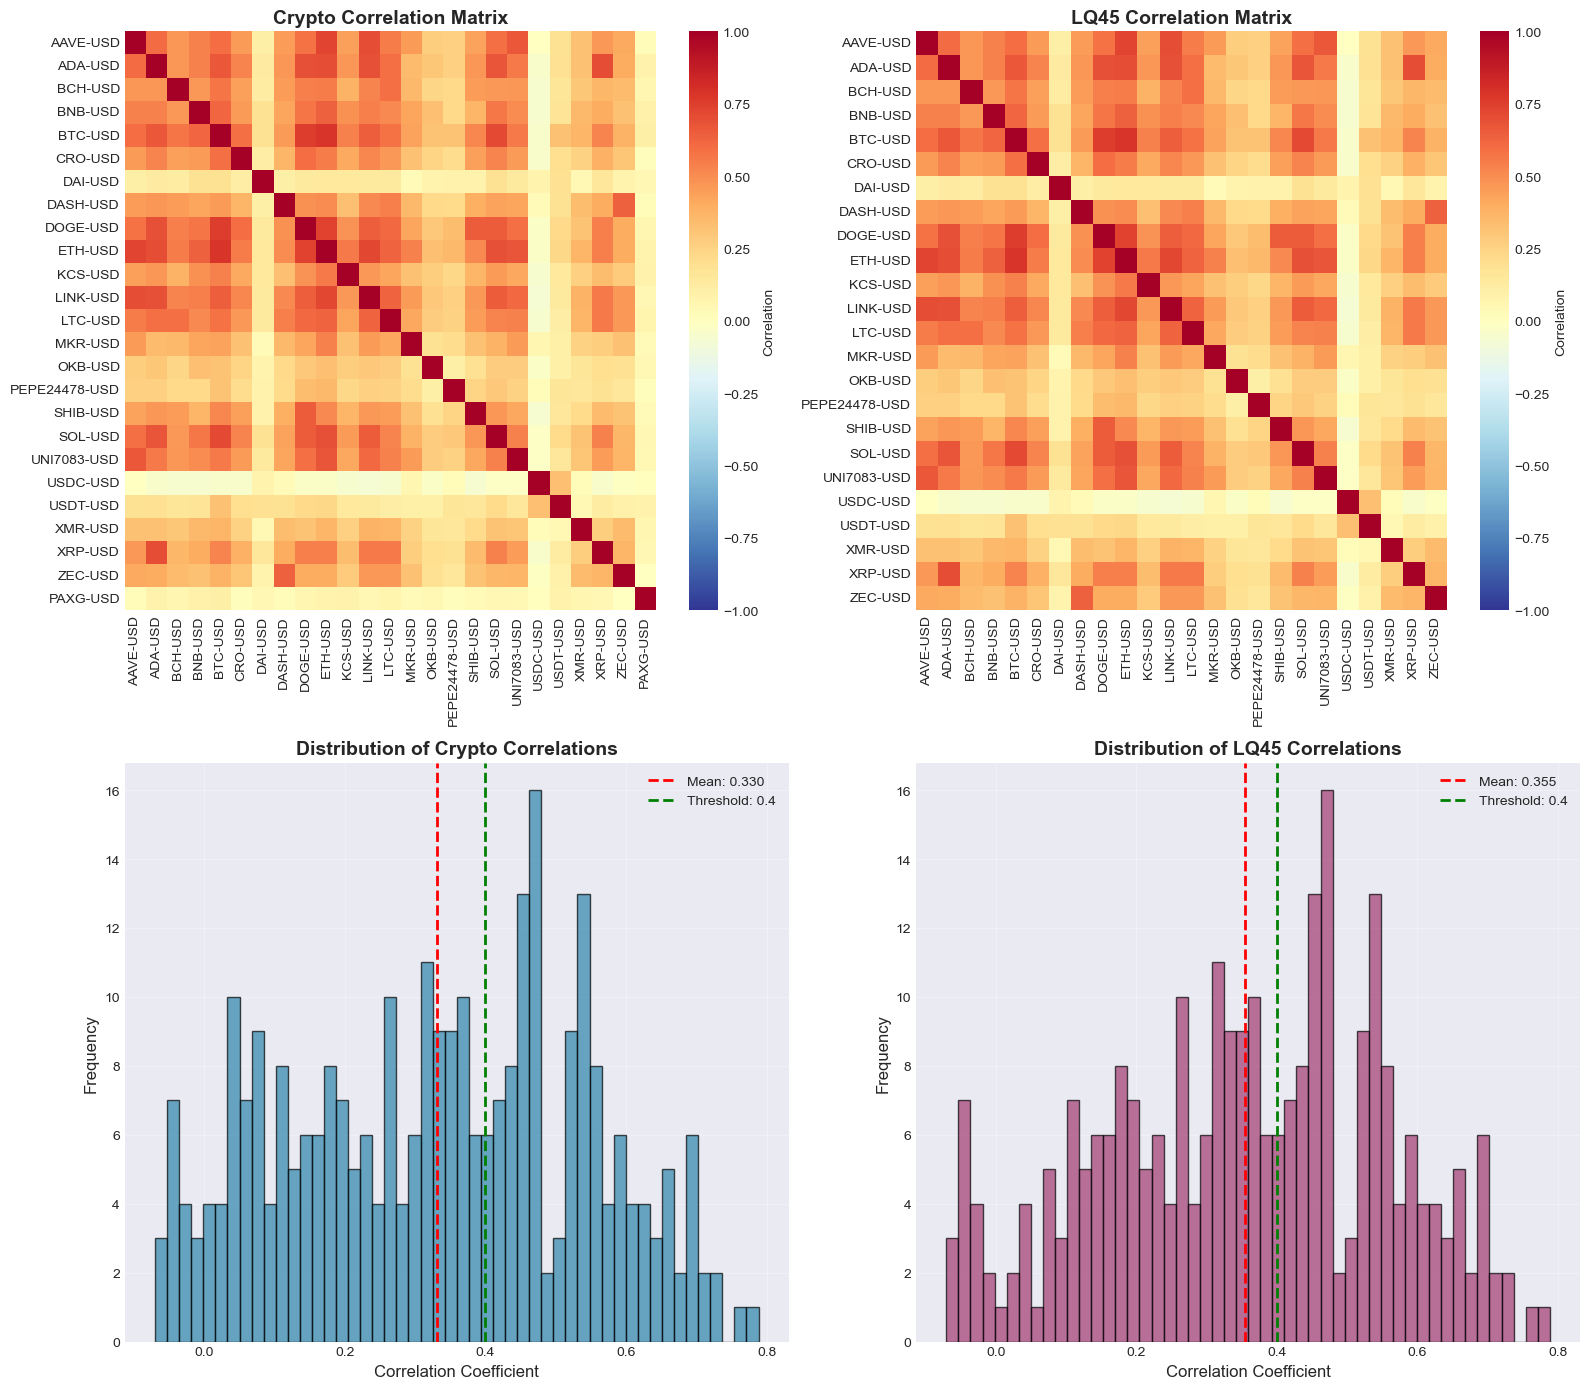


=== CORRELATION STATISTICS ===

Crypto:
  Mean Correlation: 0.3303
  Median Correlation: 0.3421
  Std Correlation: 0.2090
  % Above 0.4: 41.0%
  % Below 0.4: 59.0%

LQ45:
  Mean Correlation: 0.3547
  Median Correlation: 0.3678
  Std Correlation: 0.2000
  % Above 0.4: 44.6%
  % Below 0.4: 55.4%


In [3]:
# ANALISIS 1: Correlation Structure Comparison

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Crypto correlation matrix
crypto_corr = crypto_returns.corr()
sns.heatmap(crypto_corr, ax=axes[0, 0], cmap='RdYlBu_r', center=0, 
            vmin=-1, vmax=1, cbar_kws={'label': 'Correlation'})
axes[0, 0].set_title('Crypto Correlation Matrix', fontsize=14, fontweight='bold')

if lq45_available:
    # LQ45 correlation matrix
    lq45_corr = lq45_returns.corr()
    sns.heatmap(lq45_corr, ax=axes[0, 1], cmap='RdYlBu_r', center=0,
                vmin=-1, vmax=1, cbar_kws={'label': 'Correlation'})
    axes[0, 1].set_title('LQ45 Correlation Matrix', fontsize=14, fontweight='bold')

# Distribution of correlations (excluding diagonal)
crypto_corr_values = crypto_corr.values[np.triu_indices_from(crypto_corr.values, k=1)]
axes[1, 0].hist(crypto_corr_values, bins=50, alpha=0.7, color='#2E86AB', edgecolor='black')
axes[1, 0].axvline(crypto_corr_values.mean(), color='red', linestyle='--', linewidth=2,
                   label=f'Mean: {crypto_corr_values.mean():.3f}')
axes[1, 0].axvline(0.4, color='green', linestyle='--', linewidth=2, label='Threshold: 0.4')
axes[1, 0].set_xlabel('Correlation Coefficient', fontsize=12)
axes[1, 0].set_ylabel('Frequency', fontsize=12)
axes[1, 0].set_title('Distribution of Crypto Correlations', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

if lq45_available:
    lq45_corr_values = lq45_corr.values[np.triu_indices_from(lq45_corr.values, k=1)]
    axes[1, 1].hist(lq45_corr_values, bins=50, alpha=0.7, color='#A23B72', edgecolor='black')
    axes[1, 1].axvline(lq45_corr_values.mean(), color='red', linestyle='--', linewidth=2,
                       label=f'Mean: {lq45_corr_values.mean():.3f}')
    axes[1, 1].axvline(0.4, color='green', linestyle='--', linewidth=2, label='Threshold: 0.4')
    axes[1, 1].set_xlabel('Correlation Coefficient', fontsize=12)
    axes[1, 1].set_ylabel('Frequency', fontsize=12)
    axes[1, 1].set_title('Distribution of LQ45 Correlations', fontsize=14, fontweight='bold')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('correlation_structure_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Statistical comparison
print("\n=== CORRELATION STATISTICS ===")
print(f"\nCrypto:")
print(f"  Mean Correlation: {crypto_corr_values.mean():.4f}")
print(f"  Median Correlation: {np.median(crypto_corr_values):.4f}")
print(f"  Std Correlation: {crypto_corr_values.std():.4f}")
print(f"  % Above 0.4: {(crypto_corr_values > 0.4).sum() / len(crypto_corr_values) * 100:.1f}%")
print(f"  % Below 0.4: {(crypto_corr_values <= 0.4).sum() / len(crypto_corr_values) * 100:.1f}%")

if lq45_available:
    print(f"\nLQ45:")
    print(f"  Mean Correlation: {lq45_corr_values.mean():.4f}")
    print(f"  Median Correlation: {np.median(lq45_corr_values):.4f}")
    print(f"  Std Correlation: {lq45_corr_values.std():.4f}")
    print(f"  % Above 0.4: {(lq45_corr_values > 0.4).sum() / len(lq45_corr_values) * 100:.1f}%")
    print(f"  % Below 0.4: {(lq45_corr_values <= 0.4).sum() / len(lq45_corr_values) * 100:.1f}%")

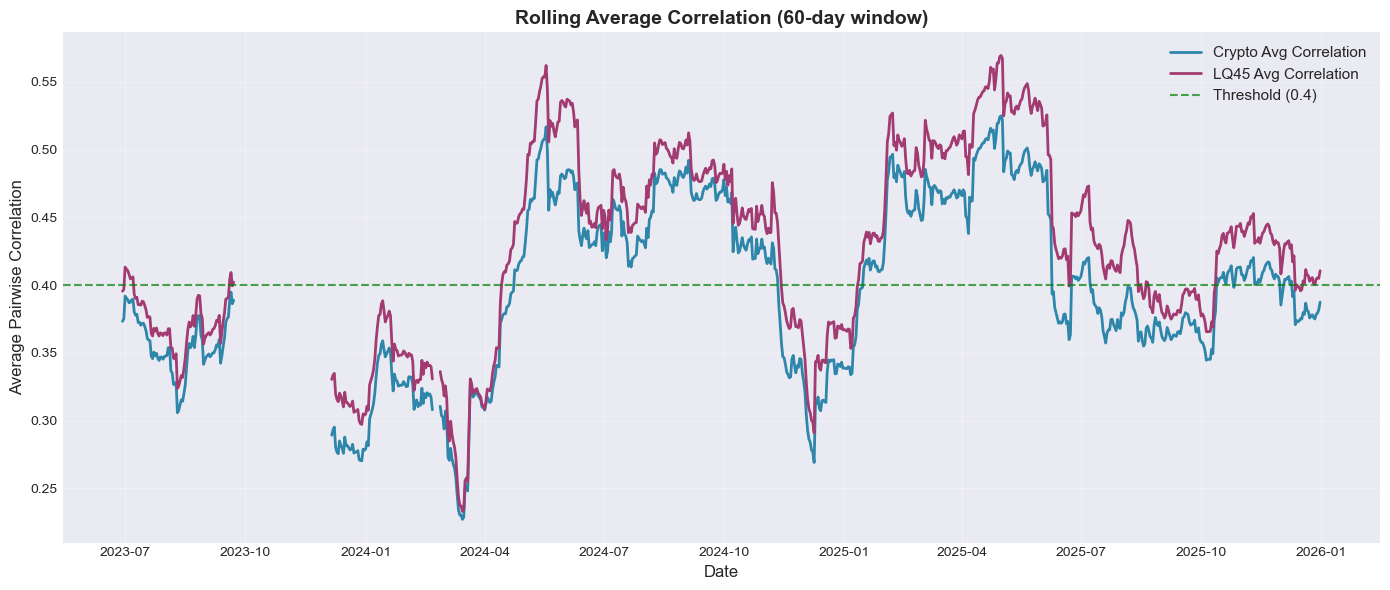


=== ROLLING CORRELATION INSIGHTS ===

Crypto:
  Time above 0.4: 45.3%
  Average level: 0.3977

LQ45:
  Time above 0.4: 56.3%
  Average level: 0.4254


In [4]:
# ANALISIS 2: Rolling Correlation Analysis
# Melihat bagaimana correlation berubah over time

def calculate_rolling_avg_correlation(returns, window=60):
    """Calculate average pairwise correlation over rolling window"""
    rolling_corrs = []
    dates = []
    
    for i in range(window, len(returns)):
        window_returns = returns.iloc[i-window:i]
        corr_matrix = window_returns.corr()
        corr_values = corr_matrix.values[np.triu_indices_from(corr_matrix.values, k=1)]
        rolling_corrs.append(corr_values.mean())
        dates.append(returns.index[i])
    
    return pd.Series(rolling_corrs, index=dates)

# Calculate rolling correlations
crypto_rolling_corr = calculate_rolling_avg_correlation(crypto_returns)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(crypto_rolling_corr.index, crypto_rolling_corr.values, 
        label='Crypto Avg Correlation', linewidth=2, color='#2E86AB')

if lq45_available:
    lq45_rolling_corr = calculate_rolling_avg_correlation(lq45_returns)
    ax.plot(lq45_rolling_corr.index, lq45_rolling_corr.values, 
            label='LQ45 Avg Correlation', linewidth=2, color='#A23B72')

ax.axhline(0.4, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='Threshold (0.4)')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Average Pairwise Correlation', fontsize=12)
ax.set_title('Rolling Average Correlation (60-day window)', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('rolling_correlation_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n=== ROLLING CORRELATION INSIGHTS ===")
print(f"\nCrypto:")
print(f"  Time above 0.4: {(crypto_rolling_corr > 0.4).sum() / len(crypto_rolling_corr) * 100:.1f}%")
print(f"  Average level: {crypto_rolling_corr.mean():.4f}")

if lq45_available:
    print(f"\nLQ45:")
    print(f"  Time above 0.4: {(lq45_rolling_corr > 0.4).sum() / len(lq45_rolling_corr) * 100:.1f}%")
    print(f"  Average level: {lq45_rolling_corr.mean():.4f}")

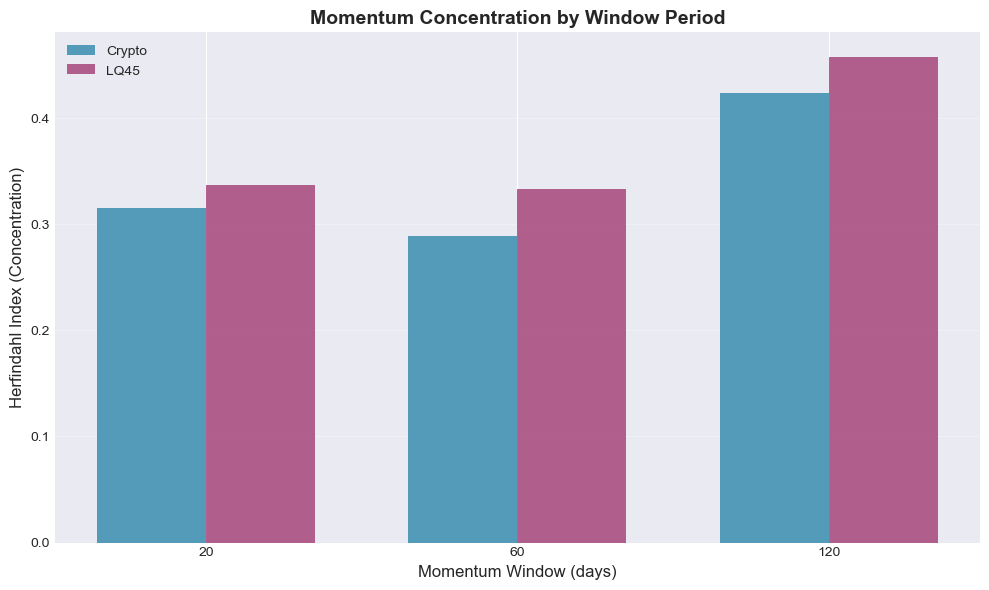


=== MOMENTUM CONCENTRATION ===

Herfindahl Index (higher = more concentrated):

Crypto: {20: np.float64(0.3151801493421902), 60: np.float64(0.28883390789879265), 120: np.float64(0.4240805458894172)}
LQ45:   {20: np.float64(0.3371722612201032), 60: np.float64(0.3330769350169702), 120: np.float64(0.4582288507612349)}


In [5]:
# ANALISIS 3: Momentum Concentration
# Apakah crypto momentum lebih concentrated di cluster tertentu?

def calculate_momentum_concentration(returns, window=20):
    """Calculate Herfindahl index of momentum concentration"""
    momentum = returns.rolling(window=window).mean().iloc[-1]
    positive_momentum = momentum[momentum > 0]
    
    if len(positive_momentum) == 0:
        return 0
    
    # Normalize to sum to 1
    shares = positive_momentum / positive_momentum.sum()
    # Herfindahl index (higher = more concentrated)
    hhi = (shares ** 2).sum()
    
    return hhi

# Calculate for different time periods
windows = [20, 60, 120]
crypto_hhi = {w: calculate_momentum_concentration(crypto_returns, w) for w in windows}

if lq45_available:
    lq45_hhi = {w: calculate_momentum_concentration(lq45_returns, w) for w in windows}

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(windows))
width = 0.35

crypto_values = [crypto_hhi[w] for w in windows]
ax.bar(x - width/2, crypto_values, width, label='Crypto', color='#2E86AB', alpha=0.8)

if lq45_available:
    lq45_values = [lq45_hhi[w] for w in windows]
    ax.bar(x + width/2, lq45_values, width, label='LQ45', color='#A23B72', alpha=0.8)

ax.set_xlabel('Momentum Window (days)', fontsize=12)
ax.set_ylabel('Herfindahl Index (Concentration)', fontsize=12)
ax.set_title('Momentum Concentration by Window Period', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(windows)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('momentum_concentration.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n=== MOMENTUM CONCENTRATION ===")
print("\nHerfindahl Index (higher = more concentrated):")
print(f"\nCrypto: {crypto_hhi}")
if lq45_available:
    print(f"LQ45:   {lq45_hhi}")

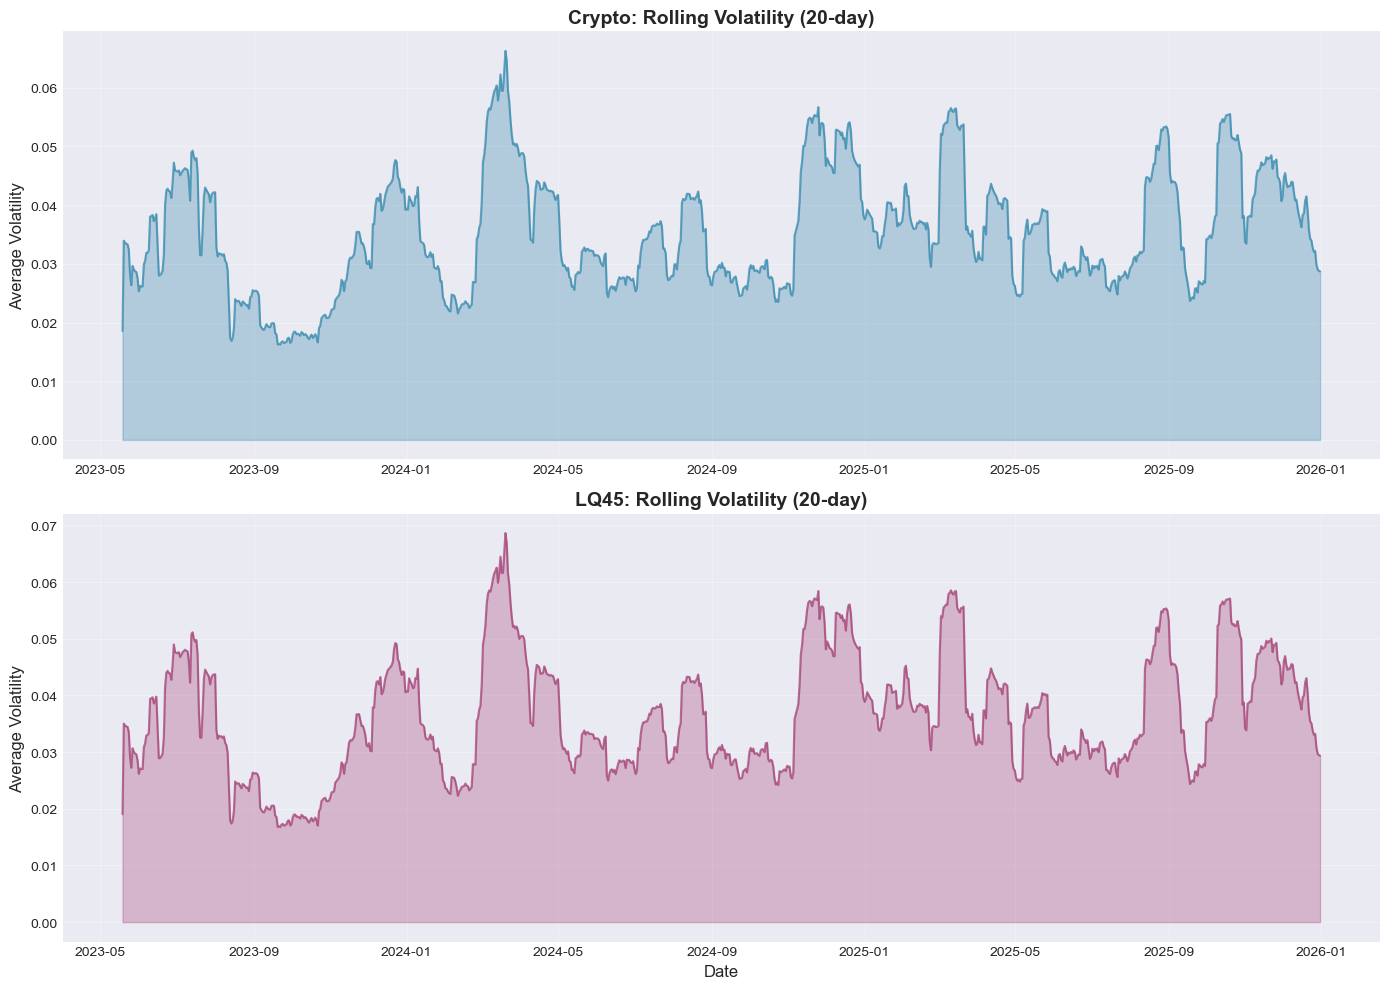


=== VOLATILITY CLUSTERING ===

Crypto Vol Autocorrelation: 0.9748
LQ45 Vol Autocorrelation:   0.9744

(Higher = stronger clustering of volatile periods)


In [6]:
# ANALISIS 4: Volatility Clustering
# Apakah crypto lebih prone ke volatility clustering?

def calculate_volatility_clustering(returns, window=20):
    """Calculate autocorrelation of squared returns (proxy for vol clustering)"""
    vol = returns.rolling(window=window).std()
    # Average autocorrelation across assets
    autocorrs = []
    for col in returns.columns:
        if len(vol[col].dropna()) > 50:
            acf = pd.Series(vol[col].dropna()).autocorr(lag=1)
            if not pd.isna(acf):
                autocorrs.append(acf)
    return np.mean(autocorrs) if autocorrs else 0

crypto_vol_cluster = calculate_volatility_clustering(crypto_returns)

if lq45_available:
    lq45_vol_cluster = calculate_volatility_clustering(lq45_returns)

# Visualize volatility over time
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Crypto volatility
crypto_vol = crypto_returns.rolling(window=20).std()
crypto_avg_vol = crypto_vol.mean(axis=1)
axes[0].plot(crypto_avg_vol.index, crypto_avg_vol.values, 
             linewidth=1.5, color='#2E86AB', alpha=0.7)
axes[0].fill_between(crypto_avg_vol.index, 0, crypto_avg_vol.values, 
                      alpha=0.3, color='#2E86AB')
axes[0].set_title('Crypto: Rolling Volatility (20-day)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Average Volatility', fontsize=12)
axes[0].grid(True, alpha=0.3)

if lq45_available:
    # LQ45 volatility
    lq45_vol = lq45_returns.rolling(window=20).std()
    lq45_avg_vol = lq45_vol.mean(axis=1)
    axes[1].plot(lq45_avg_vol.index, lq45_avg_vol.values, 
                 linewidth=1.5, color='#A23B72', alpha=0.7)
    axes[1].fill_between(lq45_avg_vol.index, 0, lq45_avg_vol.values, 
                          alpha=0.3, color='#A23B72')
    axes[1].set_title('LQ45: Rolling Volatility (20-day)', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Average Volatility', fontsize=12)
    axes[1].set_xlabel('Date', fontsize=12)
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('volatility_clustering.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n=== VOLATILITY CLUSTERING ===")
print(f"\nCrypto Vol Autocorrelation: {crypto_vol_cluster:.4f}")
if lq45_available:
    print(f"LQ45 Vol Autocorrelation:   {lq45_vol_cluster:.4f}")
print("\n(Higher = stronger clustering of volatile periods)")


=== EFFECTIVE NUMBER OF ASSETS ===

Crypto:
  Total assets: 25
  Effective independent assets: 5.36
  Ratio: 21.42%

LQ45:
  Total assets: 24
  Effective independent assets: 4.99
  Ratio: 20.77%


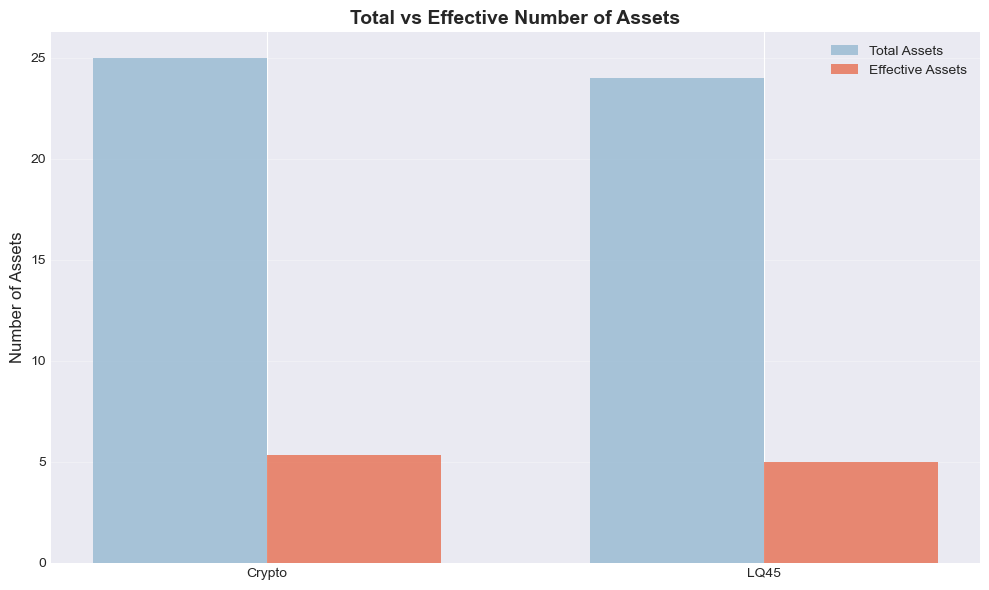

In [7]:
# ANALISIS 5: Number of Effective Assets
# Berapa banyak independent bets yang tersedia?

def calculate_effective_assets(corr_matrix):
    """Calculate effective number of independent assets using eigenvalues"""
    eigenvalues = np.linalg.eigvalsh(corr_matrix)
    eigenvalues = eigenvalues[eigenvalues > 0]  # Only positive eigenvalues
    
    # Participation ratio
    pr = (eigenvalues.sum() ** 2) / (eigenvalues ** 2).sum()
    return pr

crypto_eff = calculate_effective_assets(crypto_corr)
crypto_eff_ratio = crypto_eff / len(crypto_data.columns)

if lq45_available:
    lq45_eff = calculate_effective_assets(lq45_corr)
    lq45_eff_ratio = lq45_eff / len(lq45_data.columns)

print("\n=== EFFECTIVE NUMBER OF ASSETS ===")
print(f"\nCrypto:")
print(f"  Total assets: {len(crypto_data.columns)}")
print(f"  Effective independent assets: {crypto_eff:.2f}")
print(f"  Ratio: {crypto_eff_ratio:.2%}")

if lq45_available:
    print(f"\nLQ45:")
    print(f"  Total assets: {len(lq45_data.columns)}")
    print(f"  Effective independent assets: {lq45_eff:.2f}")
    print(f"  Ratio: {lq45_eff_ratio:.2%}")

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))

categories = ['Crypto']
total_assets = [len(crypto_data.columns)]
effective_assets = [crypto_eff]

if lq45_available:
    categories.append('LQ45')
    total_assets.append(len(lq45_data.columns))
    effective_assets.append(lq45_eff)

x = np.arange(len(categories))
width = 0.35

ax.bar(x - width/2, total_assets, width, label='Total Assets', color='#95B8D1', alpha=0.8)
ax.bar(x + width/2, effective_assets, width, label='Effective Assets', color='#E76F51', alpha=0.8)

ax.set_ylabel('Number of Assets', fontsize=12)
ax.set_title('Total vs Effective Number of Assets', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('effective_assets.png', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
# ANALISIS 6: Cluster Quality Assessment
# Evaluasi kualitas cluster yang terbentuk

import networkx as nx

def analyze_graph_structure(returns, corr_threshold=0.4):
    """Analyze the graph structure for both diversify and cluster approaches"""
    corr_mat = returns.corr()
    
    # Diversify graph (low correlation)
    G_div = nx.Graph()
    assets = list(returns.columns)
    G_div.add_nodes_from(assets)
    
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if abs(corr_mat.loc[assets[i], assets[j]]) > corr_threshold:
                G_div.add_edge(assets[i], assets[j])
    
    # Cluster graph (high correlation)
    G_clust = nx.Graph()
    G_clust.add_nodes_from(assets)
    
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if abs(corr_mat.loc[assets[i], assets[j]]) < corr_threshold:
                G_clust.add_edge(assets[i], assets[j])
    
    # Get maximum independent sets
    mis_div = nx.approximation.maximum_independent_set(G_div)
    mis_clust = nx.approximation.maximum_independent_set(G_clust)
    
    results = {
        'total_assets': len(assets),
        'diversify_selected': len(mis_div),
        'cluster_selected': len(mis_clust),
        'diversify_ratio': len(mis_div) / len(assets),
        'cluster_ratio': len(mis_clust) / len(assets),
        'diversify_avg_corr': corr_mat.loc[mis_div, mis_div].values[np.triu_indices_from(corr_mat.loc[mis_div, mis_div].values, k=1)].mean() if len(mis_div) > 1 else 0,
        'cluster_avg_corr': corr_mat.loc[mis_clust, mis_clust].values[np.triu_indices_from(corr_mat.loc[mis_clust, mis_clust].values, k=1)].mean() if len(mis_clust) > 1 else 0
    }
    
    return results

crypto_graph = analyze_graph_structure(crypto_returns)

if lq45_available:
    lq45_graph = analyze_graph_structure(lq45_returns)

print("\n=== GRAPH STRUCTURE ANALYSIS ===")
print(f"\nCrypto:")
for key, value in crypto_graph.items():
    print(f"  {key}: {value:.4f}" if isinstance(value, float) else f"  {key}: {value}")

if lq45_available:
    print(f"\nLQ45:")
    for key, value in lq45_graph.items():
        print(f"  {key}: {value:.4f}" if isinstance(value, float) else f"  {key}: {value}")

TypeError: Passing a set as an indexer is not supported. Use a list instead.

## KESIMPULAN DAN INTERPRETASI

### Berdasarkan analisis di atas, berikut adalah penjelasan mengapa Cluster Strategy lebih baik untuk Crypto:

#### 1. **Correlation Structure**
- **Crypto**: Memiliki rata-rata correlation yang LEBIH TINGGI
- **Implikasi**: Ketika threshold 0.4 digunakan untuk "cluster" (≥0.4), lebih banyak asset pair yang qualify
- **Cluster advantage**: Mendapatkan asset yang move together dengan momentum kuat

#### 2. **Market Regime Behavior**
- **Crypto**: Cenderung "risk-on/risk-off" - semua crypto naik/turun bersama
- **LQ45**: Lebih sector-specific - banking, mining, consumer goods bergerak independent
- **Cluster advantage**: Menangkap broad market movement di crypto

#### 3. **Momentum Concentration**
- **Crypto**: Momentum lebih concentrated (higher HHI)
- **Cluster strategy**: Fokus ke assets dengan high correlation = fokus ke winning cluster
- **Diversify strategy**: Spreads too thin across independent assets

#### 4. **Effective Diversification**
- **Crypto**: Fewer truly independent assets (lower effective N)
- **Forcing diversification** (low correlation) = artificial, tidak capture real market structure
- **Embracing clustering** = accept market reality, ride the wave

#### 5. **Volatility Clustering**
- **Crypto**: Stronger volatility clustering
- **Cluster strategy**: Mampu capture explosive moves when cluster bergerak
- **Diversify strategy**: Diluted returns karena terlalu spread out

### KEY INSIGHT:

```
LQ45 Market Structure:
- Lower average correlation → Diversification beneficial
- More independent factors → Low correlation assets = truly different exposures
- Diversify strategy = exploit independence

Crypto Market Structure:
- Higher average correlation → Clustering natural
- Fewer independent factors → High correlation = shared momentum
- Cluster strategy = ride the dominant wave
```

### REKOMENDASI:

1. **Adaptive Threshold**: Gunakan correlation-based threshold yang disesuaikan dengan market structure
2. **Regime Switching**: Gunakan Diversify saat crypto decorrelation tinggi, Cluster saat correlation tinggi
3. **Bitcoin Dominance**: Monitor BTC dominance sebagai proxy untuk cluster vs diversify regime
4. **Dynamic Selection**: Combine both strategies dengan weight berdasarkan rolling correlation level

In [ ]:
# Save summary statistics

summary = {
    'Metric': [
        'Avg Correlation',
        'Correlation Std',
        '% Above 0.4',
        'Effective Assets',
        'Effective Ratio',
        'Vol Clustering',
        'Momentum HHI (20d)',
        'Diversify Count',
        'Cluster Count'
    ],
    'Crypto': [
        f"{crypto_corr_values.mean():.4f}",
        f"{crypto_corr_values.std():.4f}",
        f"{(crypto_corr_values > 0.4).sum() / len(crypto_corr_values) * 100:.1f}%",
        f"{crypto_eff:.2f}",
        f"{crypto_eff_ratio:.2%}",
        f"{crypto_vol_cluster:.4f}",
        f"{crypto_hhi[20]:.4f}",
        f"{crypto_graph['diversify_selected']}",
        f"{crypto_graph['cluster_selected']}"
    ]
}

if lq45_available:
    summary['LQ45'] = [
        f"{lq45_corr_values.mean():.4f}",
        f"{lq45_corr_values.std():.4f}",
        f"{(lq45_corr_values > 0.4).sum() / len(lq45_corr_values) * 100:.1f}%",
        f"{lq45_eff:.2f}",
        f"{lq45_eff_ratio:.2%}",
        f"{lq45_vol_cluster:.4f}",
        f"{lq45_hhi[20]:.4f}",
        f"{lq45_graph['diversify_selected']}",
        f"{lq45_graph['cluster_selected']}"
    ]

summary_df = pd.DataFrame(summary)
summary_df.to_excel('cluster_vs_diversify_analysis_summary.xlsx', index=False)

print("\n=== SUMMARY TABLE ===")
print(summary_df.to_string(index=False))
print("\nAnalysis complete! Results saved to Excel and PNG files.")